# Bài thực hành 1
### Dự đoán khả năng tiến triển của bệnh tiểu đường thông qua các chỉ số sinh lý của cơ thể

In [1]:
# Import cac thu vien
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
diabetes = datasets.load_diabetes() # Ham nay co san trong sklearn, dung de load du lieu diabetes
print ("So chieu du lieu input: ", diabetes.data.shape) # In ra so chieu du lieu input
print ("Kieu du lieu input: ", type(diabetes.data)) # In ra kieu du lieu input
print ("So chieu du lieu target: ", diabetes.target.shape) # In ra so chieu du lieu target
print ("Kieu du lieu target: ", type(diabetes.target)) # In ra kieu du lieu target
print()

print ("5 mau du lieu input dau tien: ", diabetes.data[:5]) # In ra 5 mau du lieu input dau tien
print ("5 mau du lieu target dau tien: ", diabetes.target[:5]) # In ra 5 mau du lieu target dau tien

# Target la bien can du doan, trong sklearn, target la thuoc tinh cua dataset

So chieu du lieu input:  (442, 10)
Kieu du lieu input:  <class 'numpy.ndarray'>
So chieu du lieu target:  (442,)
Kieu du lieu target:  <class 'numpy.ndarray'>

5 mau du lieu input dau tien:  [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
5 mau du lieu target dau tien:  [151.  75. 141. 206. 135.]


### Chia dữ liệu làm 2 phần training 362 mẫu và testing 80 mẫu

In [4]:
# Cat nho du lieu, lay 1 phan cho qua trinh thu nghiem
# Chia train test cac mau du lieu
# diabetes_X = diabetes.data[:, np.newaxis, 2], Lay cot thu 2 cua du lieu input, va tao them 1 chieu moi

diabetes_X = diabetes.data

diabetes_X_train = diabetes_X[:361]
diabetes_y_train = diabetes.target[:361]

diabetes_X_test = diabetes_X[362:]
diabetes_y_test = diabetes.target[362:]

### Xây dựng mô hình Regression sử dụng Sklearn
Thực nghiệm xây dựng mô hình hồi quy (Linear Regression / Ridge Regression) để học được bộ tham số  
- Linear Regression: linear_model.LinearRegression()
- Ridge Regression: linear_model.Ridge()


In [5]:
# Xay dung model su dung sklearn
regr = linear_model.LinearRegression() # Khoi tao model Linear Regression

In [6]:
### Excercise ###
# Y/c: Cai dat mo hinh Ridge Regression voi alpha = 0.1
# LINK huong dan bi 404 roi =))))))
regr_ridge = linear_model.Ridge(alpha=0.1) # Khoi tao model Ridge Regression voi alpha = 0.1

# Thang alpha thuc chat chinh la lamda

### Training mô hình
Sử dụng dữ liệu đã được chia ở bước trước đó để thực hiện training model  
=> Tìm được bộ trọng số [w0, w1,..., w_n]

In [7]:
# Huan luyen mo hinh Linear Regression
regr.fit(diabetes_X_train, diabetes_y_train)
print("[w1,..., w_n] = ", regr.coef_) # In ra he so w1,..., w_n cua mo hinh Linear Regression
print("w0 = ", regr.intercept_) # In ra he so w0 cua mo hinh Linear Regression

[w1,..., w_n] =  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
w0 =  152.56041961097782


In [8]:
# Huan luyen bang mo hinh Ridge Regression
regr_ridge.fit(diabetes_X_train, diabetes_y_train)
print("[w1,..., w_n] = ", regr_ridge.coef_) # In ra he so w1,..., w_n cua mo hinh Ridge Regression
print("w0 = ", regr_ridge.intercept_) # In ra he so w0 cua mo hinh Ridge Regression

[w1,..., w_n] =  [  10.51523842 -215.21946642  477.04576811  275.18547584  -64.84522547
  -82.84458659 -194.22465786  112.99561167  427.19001456  121.18397114]
w0 =  152.57401415344637


In [9]:
### Excercise ###
# Tinh gia tri du doan cua mo hinh tren mau dau tien cua tap test va so sanh voi ket qua cua thu vien
# Su dung cong thuc y = w0 + w1*x1 + ... + w_n*x_n de tinh gia tri du doan cua mo hinh tren mau dau tien cua tap test

x = diabetes_X_test[0] # Lay mau dau tien cua tap test
y_pred_linear = regr.intercept_ + np.dot(regr.coef_, x) # Tinh gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test
print ("Gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test: ", y_pred_linear) # In ra gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test
y_pred_lib_linear = regr.predict([x]) # Tinh gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test su dung thu vien
print ("Gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test su dung thu vien: ", y_pred_lib_linear) # In ra gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test su dung thu vien

y_pred_ridge = regr_ridge.intercept_ + np.dot(regr_ridge.coef_, x) # Tinh gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test
print ("Gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test: ", y_pred_ridge) # In ra gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test
y_pred_lib_ridge = regr_ridge.predict([x]) # Tinh gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test su dung thu vien
print ("Gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test su dung thu vien: ", y_pred_lib_ridge) # In ra gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test su dung thu vien

Gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test:  234.3594787232268
Gia tri du doan cua mo hinh Linear Regression tren mau dau tien cua tap test su dung thu vien:  [234.35947872]
Gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test:  226.73474004055703
Gia tri du doan cua mo hinh Ridge Regression tren mau dau tien cua tap test su dung thu vien:  [226.73474004]


### Dự đoán các mẫu dữ liệu trong tập test


In [ ]:
# Thuc hien suy dien sau khi huan luyen (linear regression)
diabetes_y_pred_linear = regr.predict(diabetes_X_test) # Tinh gia tri du doan cua mo hinh Linear Regression tren tap test
pd.DataFrame(data = np.array([diabetes_y_test, diabetes_y_pred_linear, abs(diabetes_y_test - diabetes_y_pred_linear)]).T, columns = ["Thuc te", "Du doan", "Lech"]) # In ra ket qua so sanh giua gia tri du doan va gia tri thuc te tren tap test

,Thuc te,Du doan,Lech
0,321.0,234.359479,86.640521
1,58.0,163.999748,105.999748
2,262.0,163.520115,98.479885
3,206.0,167.189446,38.810554
4,233.0,254.806697,21.806697
...,...,...,...
75,178.0,191.710701,13.710701
76,104.0,104.626354,0.626354
77,132.0,122.693494,9.306506
78,220.0,210.454911,9.545089


In [12]:
# Thuc hien suy dien sau khi huan luyen (ridge regression)
diabetes_y_pred_ridge = regr_ridge.predict(diabetes_X_test) # Tinh gia tri du doan cua mo hinh Ridge Regression tren tap test
pd.DataFrame(data = np.array([diabetes_y_test, diabetes_y_pred_ridge, abs(diabetes_y_test - diabetes_y_pred_ridge)]).T, columns = ["Thuc te", "Du doan", "Lech"]) # In ra ket qua so sanh giua gia tri du doan va gia tri thuc te tren tap test

,Thuc te,Du doan,Lech
0,321.0,226.734740,94.265260
1,58.0,160.362117,102.362117
2,262.0,163.440461,98.559539
3,206.0,165.882673,40.117327
4,233.0,249.611342,16.611342
...,...,...,...
75,178.0,187.982157,9.982157
76,104.0,112.747621,8.747621
77,132.0,128.295963,3.704037
78,220.0,202.798449,17.201551


### Đánh giá
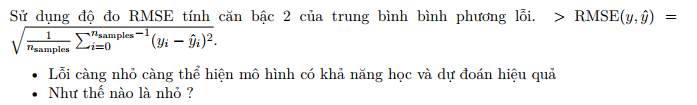

In [ ]:
print(math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred_linear))) # Tinh RMSE cua mo hinh Linear Regression tren tap test
print(math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred_ridge))) # Tinh RMSE cua mo hinh Ridge Regression tren tap test

51.53921127468042
52.34759792652382


In [15]:
### Excercise ###
# Y/c: danh gia do do RMSE cua mo hinh Ridge Regression voi cac hang so phat khac nhau, in ra ket qua
# Cac buoc lam:
# - Lap theo danh sach cac hang so phat
# - Dung cac mo hinh Ridge Regression voi moi hang so tuong ung
# - Huan luyen mo hinh va du doan
# Tinh RMSE tuong ung

# Danh sach hang so phat cho truoc:
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]

In [16]:
for alpha in _lambda:
    regr_ridge_alpha = linear_model.Ridge(alpha=alpha) # Khoi tao mo hinh Ridge Regression voi alpha tuong ung
    regr_ridge_alpha.fit(diabetes_X_train, diabetes_y_train) # Huan luyen mo hinh voi tap train
    diabetes_y_pred_ridge_alpha = regr_ridge_alpha.predict(diabetes_X_test) # Tinh gia tri du doan cua mo hinh tren tap test
    rmse = math.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred_ridge_alpha)) # Tinh RMSE cua mo hinh tren tap test
    print("Alpha: ", alpha, " - RMSE: ", rmse) # In ra ket qua

Alpha:  0  - RMSE:  51.53921127468041
Alpha:  0.0001  - RMSE:  51.546352409239795
Alpha:  0.01  - RMSE:  51.888660697856096
Alpha:  0.04  - RMSE:  52.11211596712348
Alpha:  0.05  - RMSE:  52.1525463622131
Alpha:  0.06  - RMSE:  52.19077570036307
Alpha:  0.1  - RMSE:  52.34759792652382
Alpha:  0.5  - RMSE:  54.61332151147458
Alpha:  1  - RMSE:  57.382574887617025
Alpha:  5  - RMSE:  67.24133680169886
Alpha:  10  - RMSE:  71.18738262709283
Alpha:  20  - RMSE:  74.05735936735674


### Vẽ biểu đồ phân phối cho chỉ số thực tế

,values
count,80.00000
mean,152.38750
std,78.46994
min,40.00000
25%,72.00000
50%,140.00000
75%,217.50000
max,321.00000


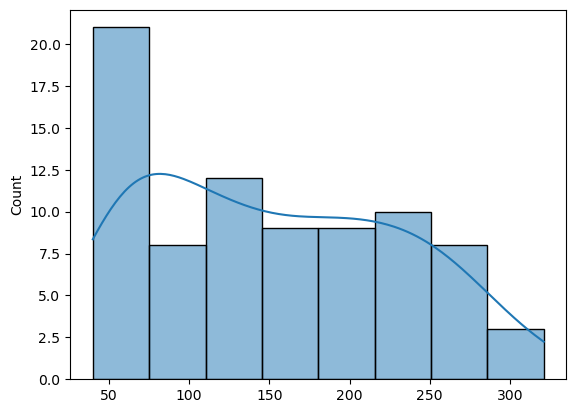

In [25]:
import seaborn as sns
sns.histplot(diabetes_y_test, kde=True)
pd.DataFrame (data = diabetes_y_test, columns = ["values"]).describe()

**Nhận xét:** Tập dữ liệu diabetes_y_test có 80 mẫu với giá trị trung bình khoảng 152. Phân phối dữ liệu hơi lệch phải và phần lớn giá trị nằm trong khoảng từ 80 đến 220.

### Vẽ biểu đồ phân phối cho chỉ số dự đoán của mô hình linear regression

        Predicted
count   80.000000
mean   155.501049
std     57.511599
min     49.193721
25%    112.399159
50%    161.143223
75%    191.047878
max    279.598577


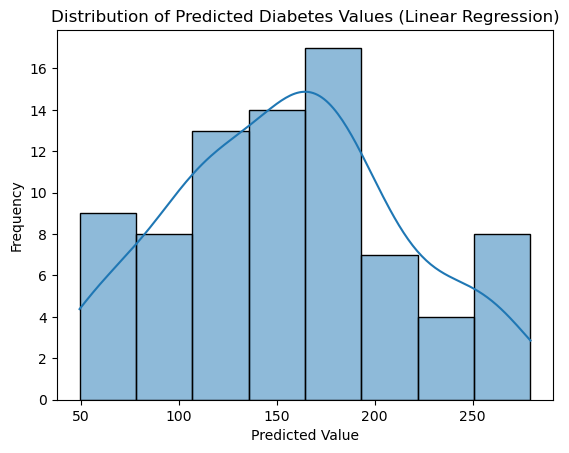

In [22]:
### Excercise ###
diabetes_y_pred_linear = regr.predict(diabetes_X_test)
print(pd.DataFrame(data=diabetes_y_pred_linear, columns=["Predicted"]).describe())

sns.histplot(diabetes_y_pred_linear, kde=True)
plt.title("Distribution of Predicted Diabetes Values (Linear Regression)")
plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.show()

**Nhận xét:** Tập dữ liệu diabetes_y_pred_linear theo mô hình linear regression có 80 mẫu với giá trị trung bình khoảng 155.5. Phân phối dữ liệu tập trung nhiều ở trung tâm và phần lớn giá trị nằm trong khoảng từ 100 đến 200.

### Vẽ biểu đồ so sánh kết quả dự đoán và thực tế

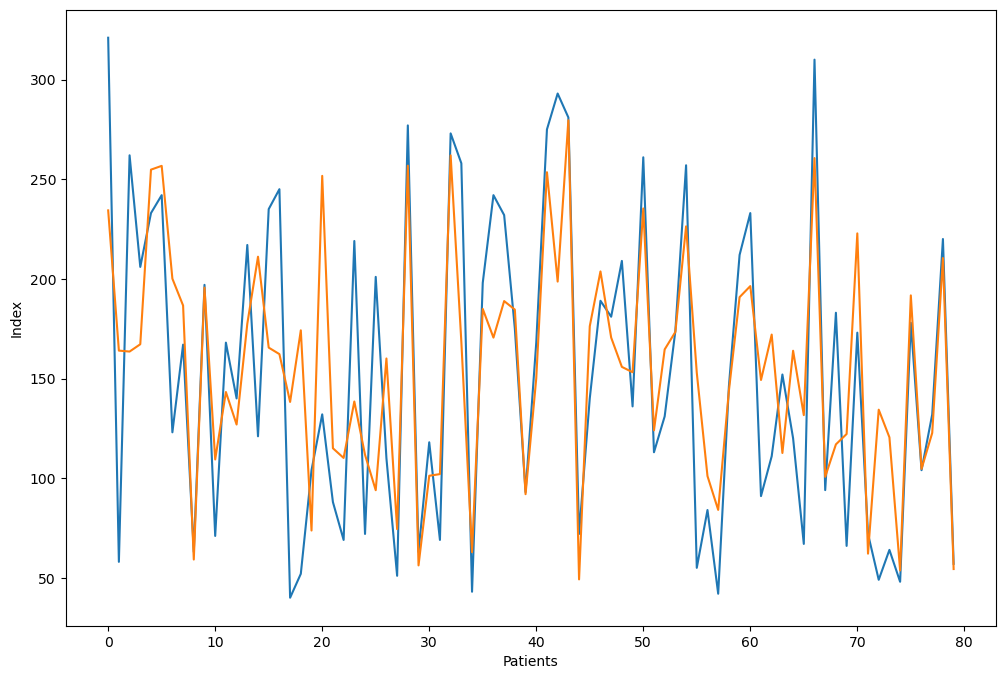

In [23]:
plt.figure(figsize=(12,8))

plt.plot(diabetes_y_test)
plt.plot(diabetes_y_pred_linear)

plt.xlabel("Patients")

plt.ylabel('Index')

plt.show()